## Lab 2: Differential Diagnosis and Conditional Expectation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [2]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


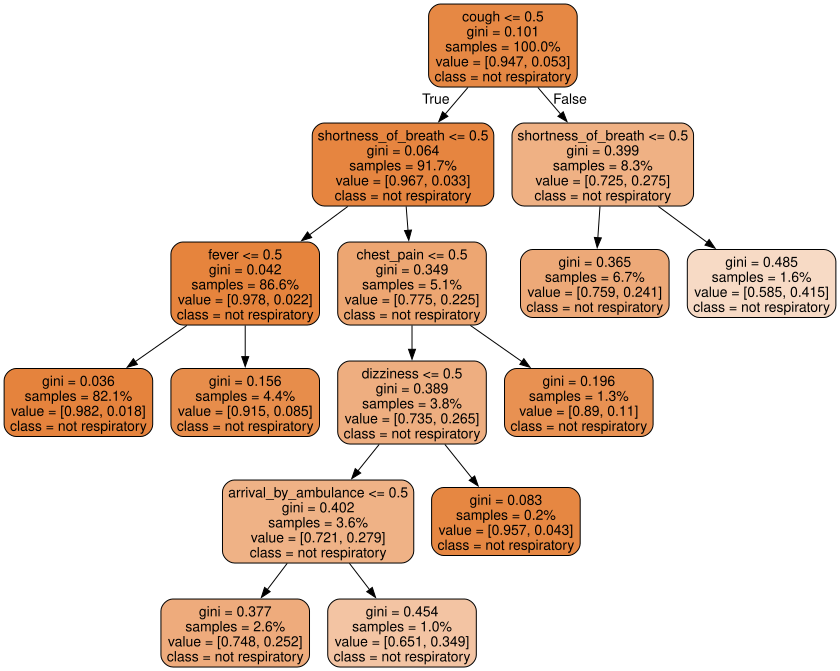

In [10]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph


The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

Which variables does the tree exploit? 

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

</div>

1) Having a cough and shortness of breath make a respiratory disease the most likely explanation. The least likely is not having a cough, not having shortness of breath, and not having a fever. 
2) The tree exploits the following varaiables: cough, shortness_of_breath, fever, chest_pain, diziness, arrival_by_ambulance. 
3) Before knowing if the individual has a cough or not, the probability of someone not having a respiratory disease is 94.7%. However if they do, then, the probability of not having it drops to 72.5% Another way of stating this is given the patient has a cough, the probability of them not having respieratory disease is 72.5%. Because we now have the information about the cough, one is able to update the probability. As one goes down the tree, one has more information and thus recieves updated probabilities. For example, given the patient has a cough and shortness of breath, the probability of them not having the disease drops to 58.5%. 
4) For 1e-3: highest= terminal leaf shows 27.5% respiratory (symptoms: has a cough) // lowest= terminal leaf shows 97.8% not respiratory (symptoms: no cough, no shortness of breath)

For 1e-5: highest= 55.5% respiratory (symptoms yes for cough, yes shortness of breath, no chest pain, no headache, yes for age over 70, and is female)  // lowest= 100% chance of not respiratory (symptoms: no cough, no shortness of breath, no fever, no chest pain, yes for accident)

For 1e-7: highest= 57.7% respiratory (symptoms: yes cough, yes shortness of breath, no chest pain, no headache, yes age over 70, is female, did not arrive by ambulance) 

Lowest Chances (all 12 terminal leaves 100% not respiratory) : 
a) no cough, no shortness of breath, yes fever, yes abdominal pain, is male, not under age 20
b)no cough, no shortness of breath, yes fever, yes abdominal pain, is female, and is between age 40 and 60
c)no cough, no shortness of breath, yes fever, no abdominal pain, yes skin rash, is female
d)no cough, no shortness of breath, yes fever, no abdominal pain, no skin rash, not over 70, yes to back pain
e)no cough, no shortness of breath, no fever, yes chest pain, yes diziness, no to arrival by ambulance, not between 20 and 40 
f) no cough, yes for shortness of breath, no chest pain, yes diziness, not over 70 and is between 40 and 60
g)no cough, no shortness of breath, no fever, yes chest pain, no diziness, yes abdominal pain, is female  
h)no cough, no shortness of breath, no fever, yes chest pain, no diziness, no abdominal pain, yes accident 
i)no cough, no shortness of breath, no fever, no chest pain, yes accident
j)no cough, no shortness of breath, no fever, no chest pain, no accident, is between 20 and 40, no back pain, no abdominal pain, no arrival by ambulance, and yes for skin rash
k)no cough, no shortness of breath, no fever, no chest pain, no accident, not between 20 and 40, is between 40 and 60, is female, yes arrival by ambulance, yes for back pain 
l) no cough, no shortness of breath, no fever, no chest pain, no accident, not between 20 and 40, is not between 40 and 60, did arrive by ambulance, not over 70, yes diziness

As the min_impurity_decrease gets smaller, the probability of predicting one has respiratory disease or not gets higher for certain set of symptoms - to the point that majority of patients having it or 100% not having it. Additionally, there are many more different outcomes when min_impurity_decrease is lower. 


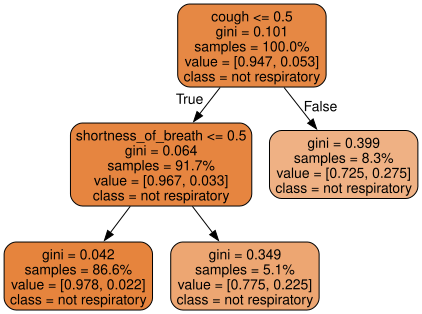

In [11]:
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph


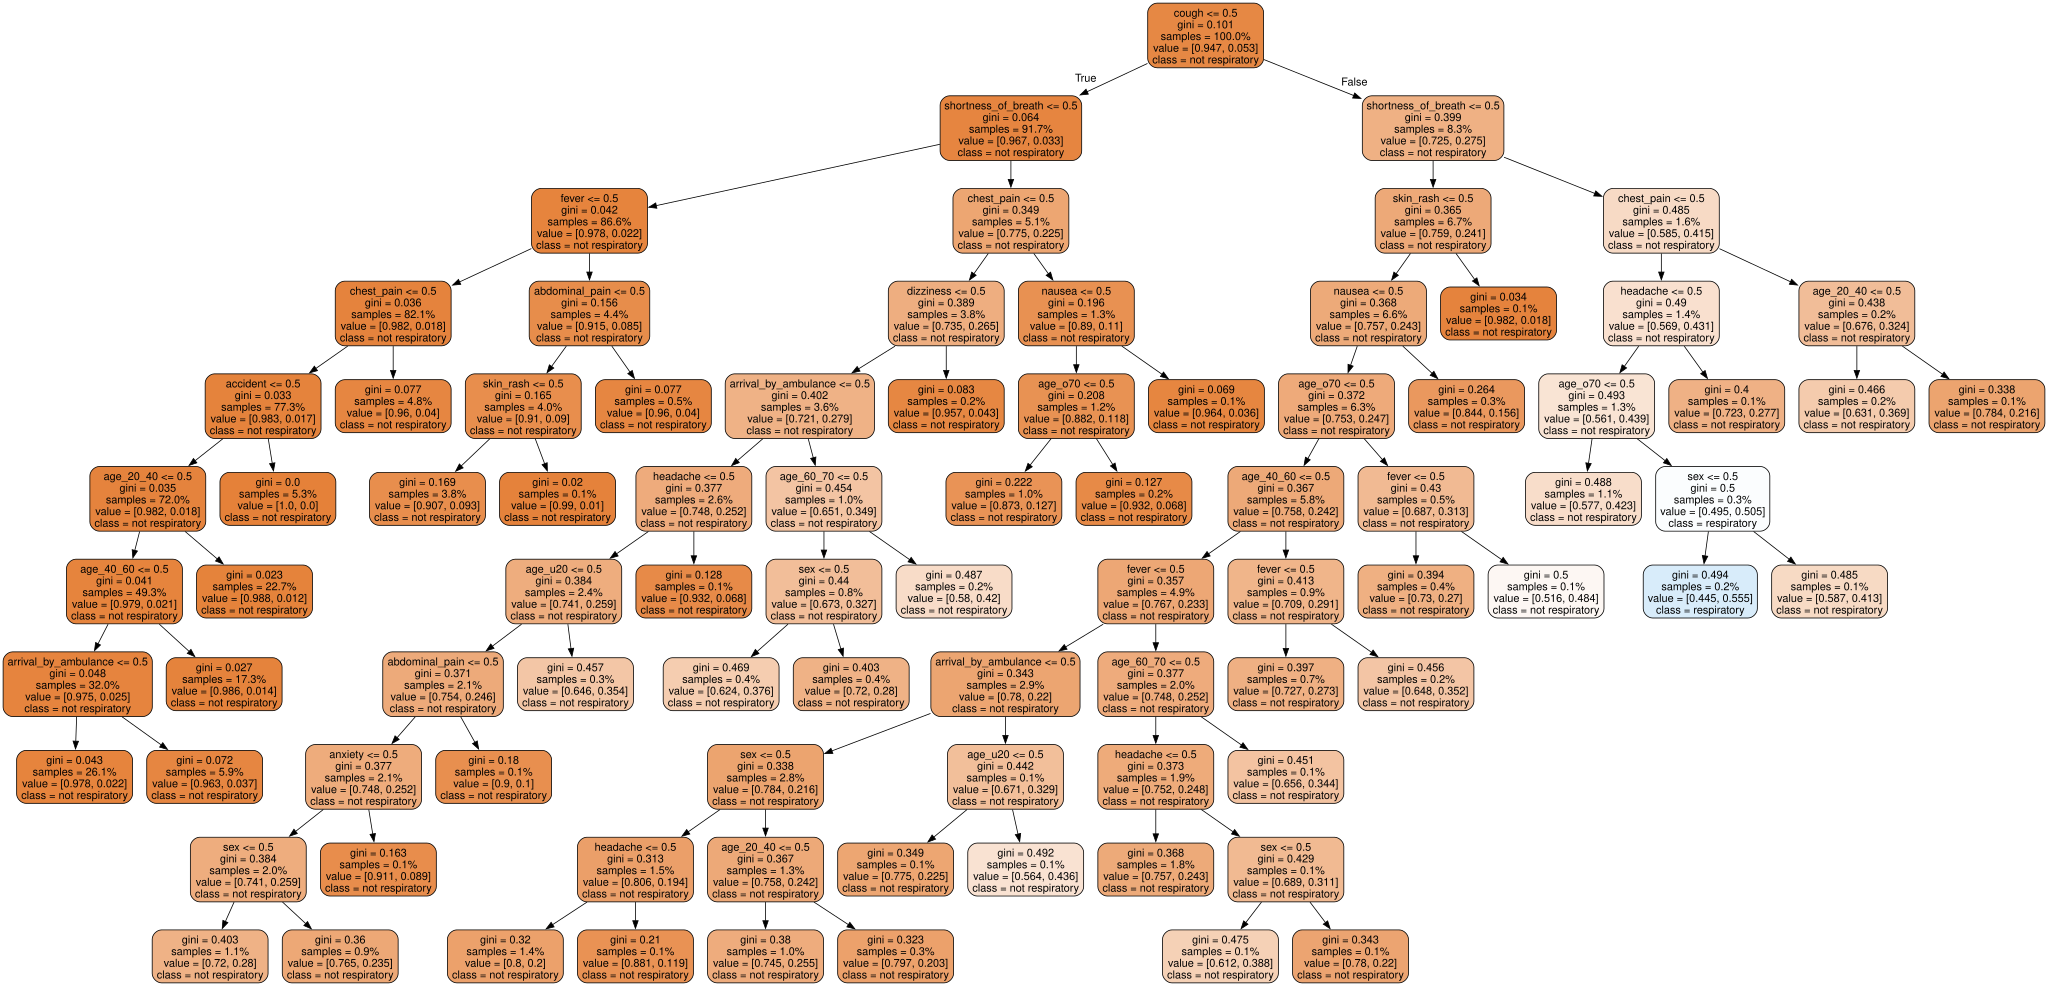

In [12]:
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-5, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph


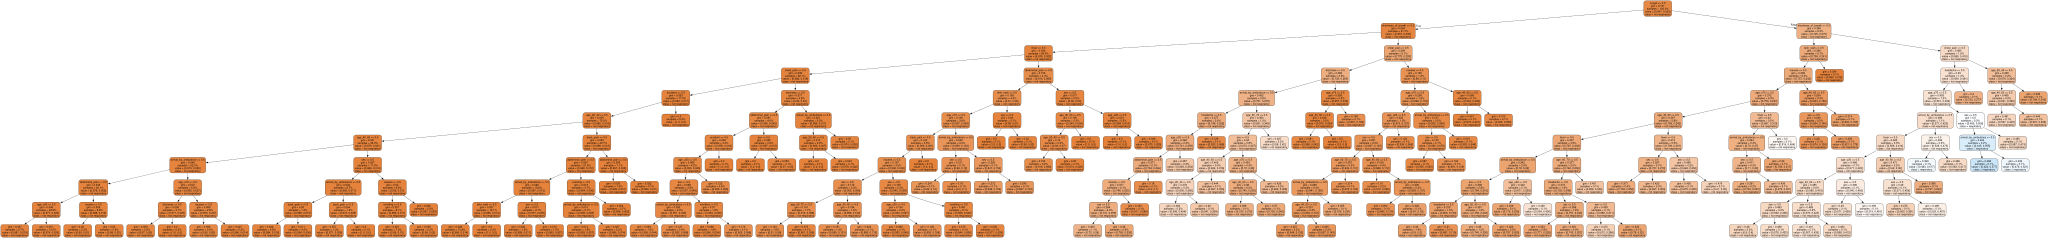

In [13]:
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-7, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph


<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

</div>

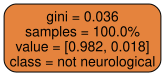

In [5]:
# Set outcome variable:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

No variables are used in the tree, and thus cannot determine what variables raised or lowered the probability of a neurological diagnosis. 

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

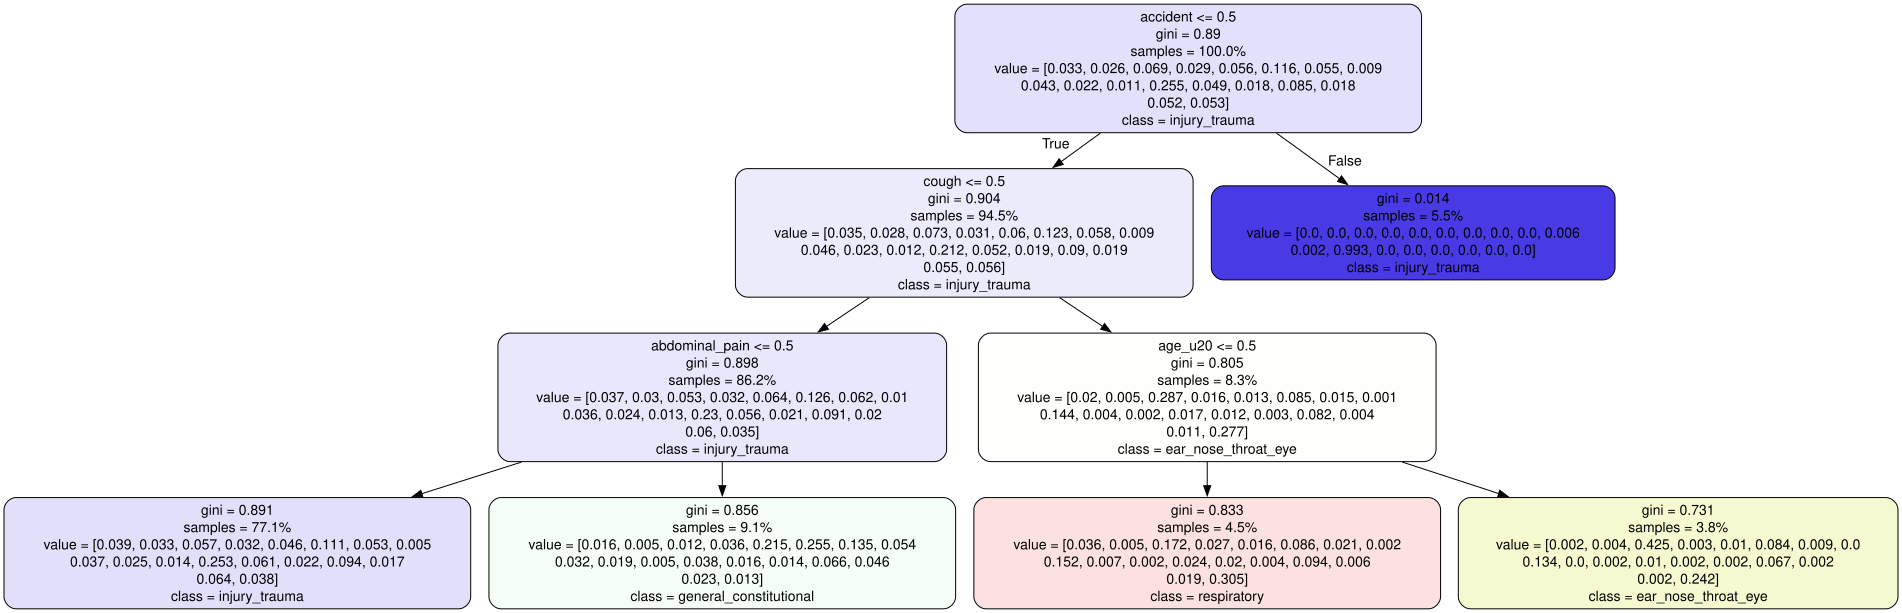

In [4]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

Which conditions and values are used in the tree?

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

</div>

1) The following are predicted as hard classifications: injury_trauma, ear_nose_throat_eye, respiratory, general_constitutional. Some of them do like injustry_trauma if the patients did have an accident, but the rest are below 0.5. The second highest probability is 0.425 with ears_nose_throat_eye. This may be a concern as it suggests that the prediction diagnosis cannot diagnose with high probability and when it does it is very vague or obvious like injury_trauma after an accident which can be a variety of things. 


2) Injury_truma (after answering False of accident, thus the patient having been in an accident) has the highest probability for a predicted disease class label with 0.993. The lowest is injury_trauma (0.253 no accident, no cough, no back pain) and then following that is general_constitutional with 0.255.
3) Conditions used are the following: if they have been in an accident, have a cough, have abdominal pain, and if patient is under 20. The value is if the patient has said condition/demographic with probability equal or less than 0.5 - meaning true if they don't have it (p=0) and false if they do as p would be =1.
4) It can still be useful for doctors as they can use the tool as one part of evaluating a patient. When there are countless things that could be the issue for a patient, the tool can still help narrow down certain illnesses/issues (with those having a very small probability comapared to others). It can help doctors guide their decision when for example deciding what further testing they should recieve. 